In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df=pd.read_csv("vehicles.csv")

In [3]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [4]:
df.shape

(426880, 26)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18  paint_color   2

In [6]:
df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [7]:
df.isnull().mean().mul(100)

id                0.000000
url               0.000000
region            0.000000
region_url        0.000000
price             0.000000
year              0.282281
manufacturer      4.133714
model             1.236179
condition        40.785232
cylinders        41.622470
fuel              0.705819
odometer          1.030735
title_status      1.930753
transmission      0.598763
VIN              37.725356
drive            30.586347
size             71.767476
type             21.752717
paint_color      30.501078
image_url         0.015930
description       0.016398
county          100.000000
state             0.000000
lat               1.534155
long              1.534155
posting_date      0.015930
dtype: float64

In [8]:
null_cols = df.columns[df.isnull().any()]
print(null_cols)
null_df = df[null_cols].isnull().sum().to_frame(name='Null Count')\
          .merge(df[null_cols].isnull().mean().mul(100).to_frame(name='Null Percent'), left_index=True, right_index=True)
null_df_sorted = null_df.sort_values(by='Null Count', ascending=False)
print(null_df_sorted)

Index(['year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size',
       'type', 'paint_color', 'image_url', 'description', 'county', 'lat',
       'long', 'posting_date'],
      dtype='str')
              Null Count  Null Percent
county            426880    100.000000
size              306361     71.767476
cylinders         177678     41.622470
condition         174104     40.785232
VIN               161042     37.725356
drive             130567     30.586347
paint_color       130203     30.501078
type               92858     21.752717
manufacturer       17646      4.133714
title_status        8242      1.930753
long                6549      1.534155
lat                 6549      1.534155
model               5277      1.236179
odometer            4400      1.030735
fuel                3013      0.705819
transmission        2556      0.598763
year                1205      0.282281
description           7

In [9]:
df=df.drop(columns=[
    "county",
    "region_url",
    "description",
    "id",
    "url",
    "lat",
    "long",
    "image_url",
    "posting_date",
    "VIN",
    "region",
    "model"
])

In [10]:
df.to_csv("CLEANDATA.csv")

In [11]:
df.isnull().mean().mul(100)

price            0.000000
year             0.282281
manufacturer     4.133714
condition       40.785232
cylinders       41.622470
fuel             0.705819
odometer         1.030735
title_status     1.930753
transmission     0.598763
drive           30.586347
size            71.767476
type            21.752717
paint_color     30.501078
state            0.000000
dtype: float64

In [12]:
df=pd.read_csv("CLEANDATA.csv")

In [13]:
df=df.dropna(subset=[
    "price",
    "year",
    "odometer",
    "manufacturer",
    "fuel",
    "transmission"
])

In [14]:
df.isnull().mean().mul(100)

Unnamed: 0       0.000000
price            0.000000
year             0.000000
manufacturer     0.000000
condition       40.217478
cylinders       41.005001
fuel             0.000000
odometer         0.000000
title_status     1.683885
transmission     0.000000
drive           30.068591
size            71.535346
type            21.220785
paint_color     30.202086
state            0.000000
dtype: float64

In [15]:
df=df[(df['price']>1500) & (df['price']<70000)]
df=df[(df['year']>2005)& (df['year']<2024)]
df=df[df['odometer']<200000]

In [16]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (290003, 15)


,Unnamed: 0,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
27,27,33590,2014.0,gmc,good,8 cylinders,gas,57923.0,clean,other,NaN,NaN,pickup,white,al
28,28,22590,2010.0,chevrolet,good,8 cylinders,gas,71229.0,clean,other,NaN,NaN,pickup,blue,al
29,29,39590,2020.0,chevrolet,good,8 cylinders,gas,19160.0,clean,other,NaN,NaN,pickup,red,al
30,30,30990,2017.0,toyota,good,8 cylinders,gas,41124.0,clean,other,NaN,NaN,pickup,red,al
31,31,15000,2013.0,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,full-size,truck,black,al


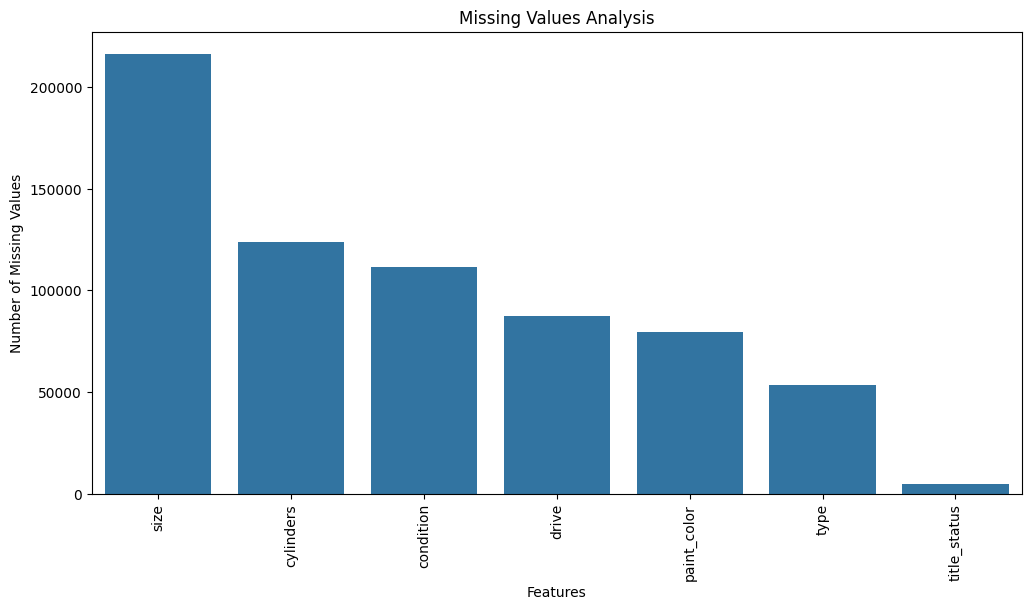

In [17]:
missing=df.isnull().sum().sort_values(ascending=False)
missing=missing[missing>0]
plt.figure(figsize=(12,6))
sns.barplot(x=missing.index,y=missing.values)
plt.title("Missing Values Analysis")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)
plt.show()

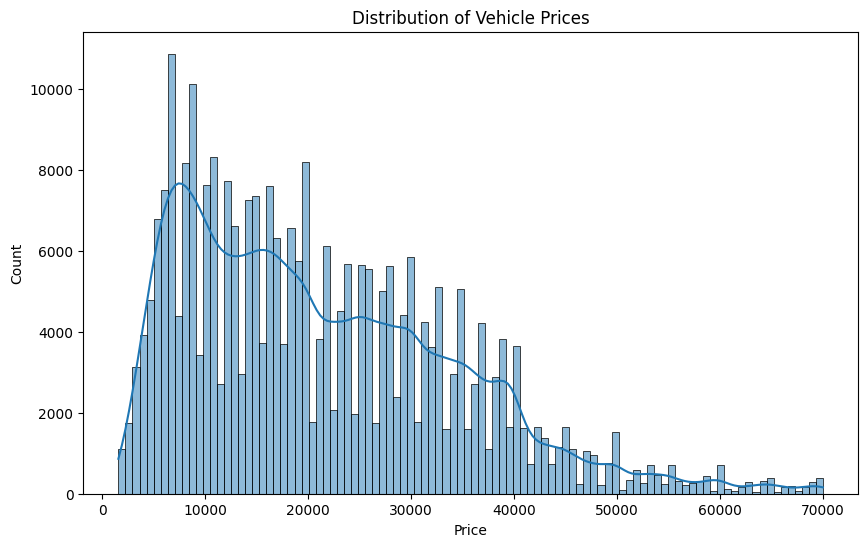

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'],bins=100,kde=True)
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price')
plt.ylabel('Count')

plt.show()

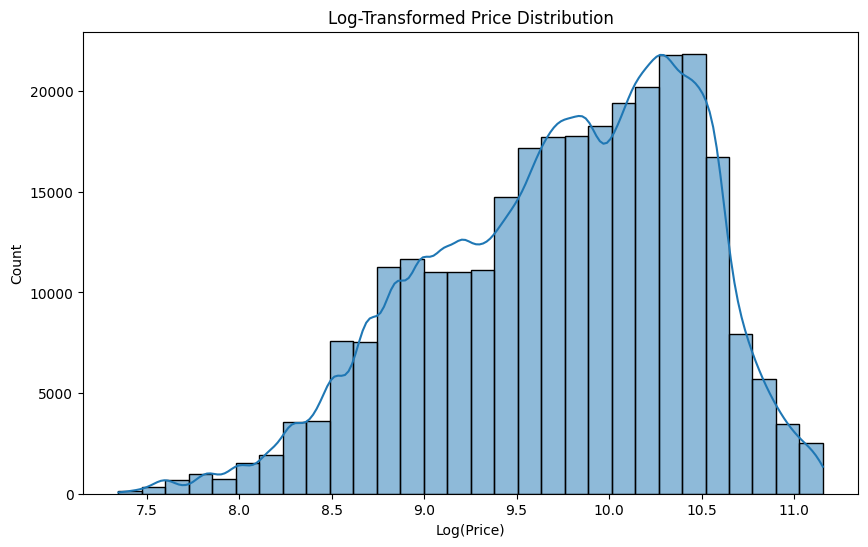

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df['price']),bins=30,kde=True)
plt.title('Log-Transformed Price Distribution')
plt.xlabel('Log(Price)')
plt.ylabel('Count')

plt.show()

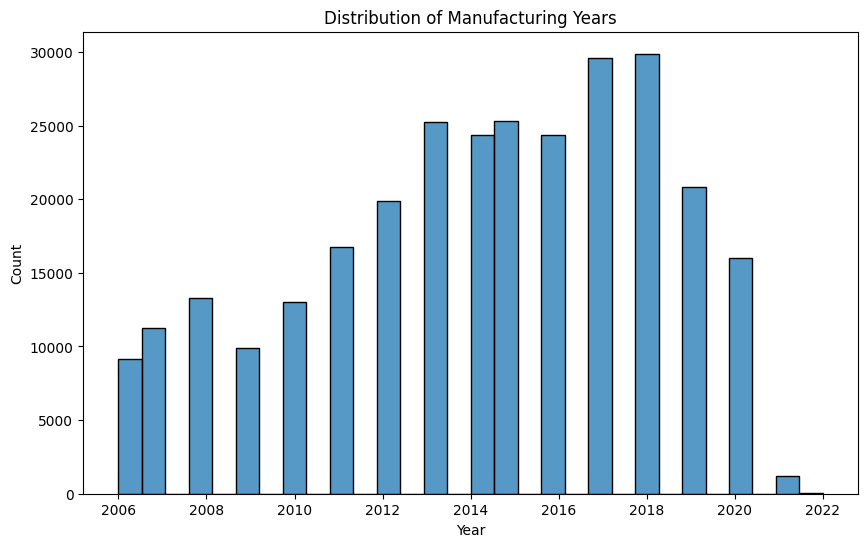

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(df['year'],bins=30)
plt.title('Distribution of Manufacturing Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

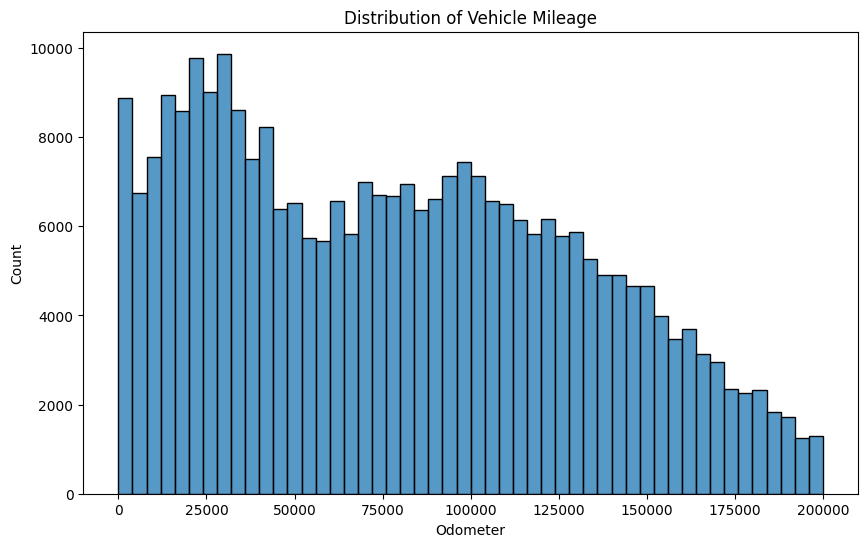

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(df['odometer'],bins=50)
plt.title('Distribution of Vehicle Mileage')
plt.xlabel('Odometer')
plt.ylabel('Count')
plt.show()

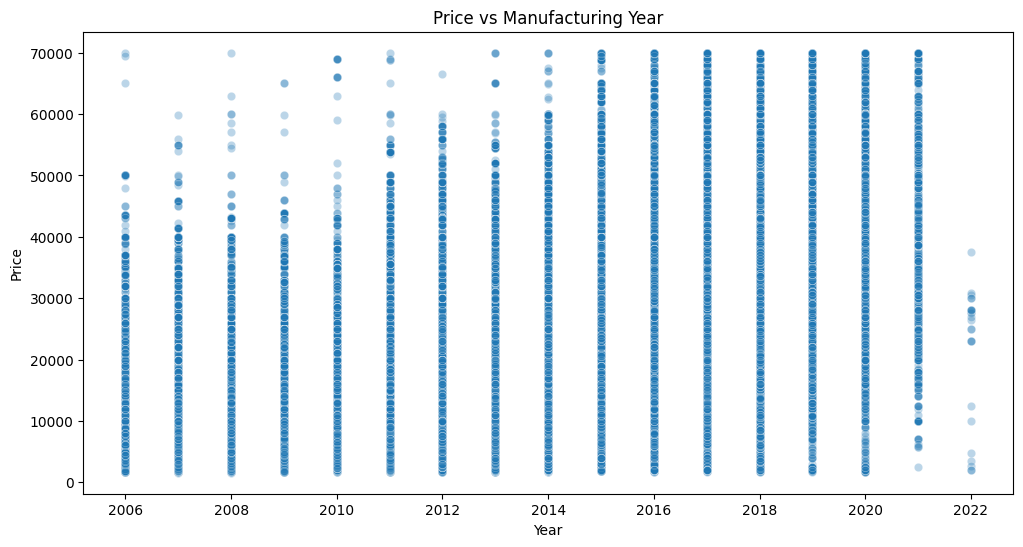

In [22]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='year',y='price',data=df,alpha=0.3)
plt.title('Price vs Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

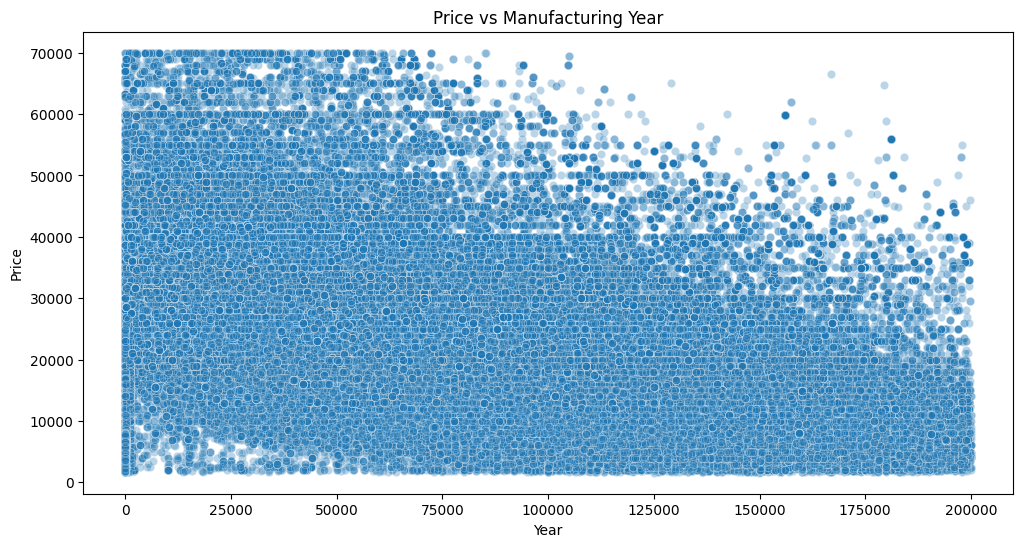

In [23]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='odometer',y='price',data=df,alpha=0.3)
plt.title('Price vs Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

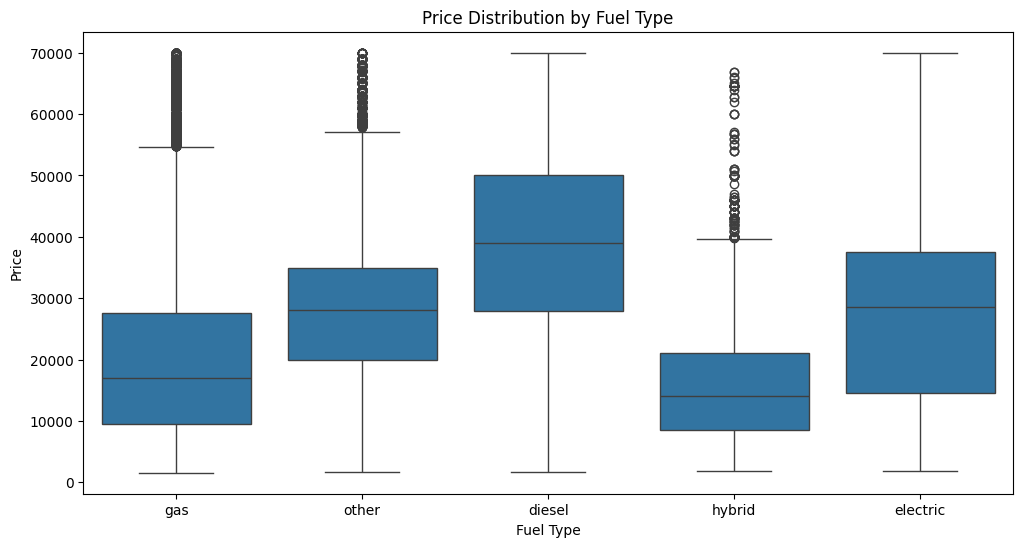

In [24]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="fuel",
    y="price"
)
plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

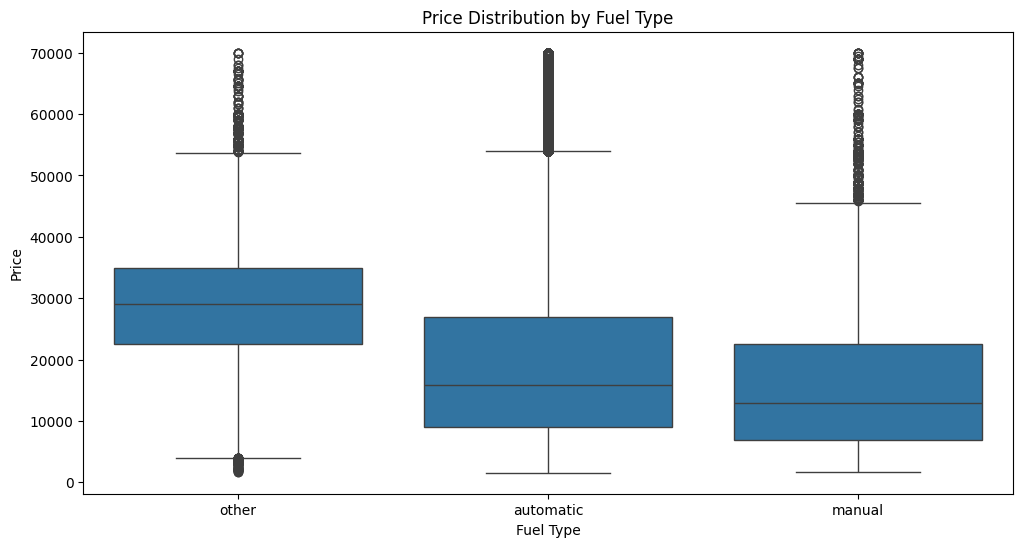

In [25]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="transmission",
    y="price"
)
plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

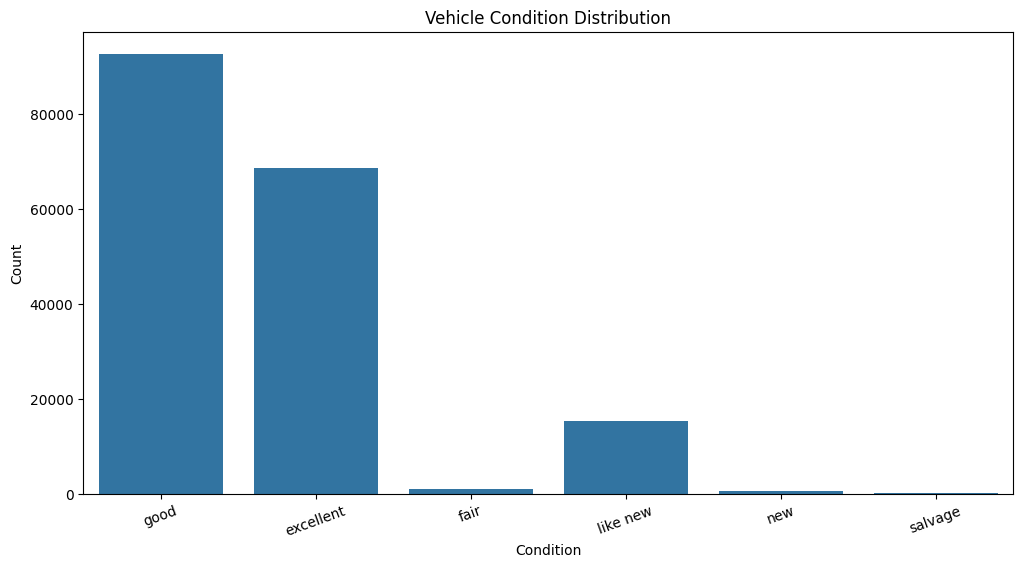

In [26]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='condition'
)
plt.title('Vehicle Condition Distribution')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

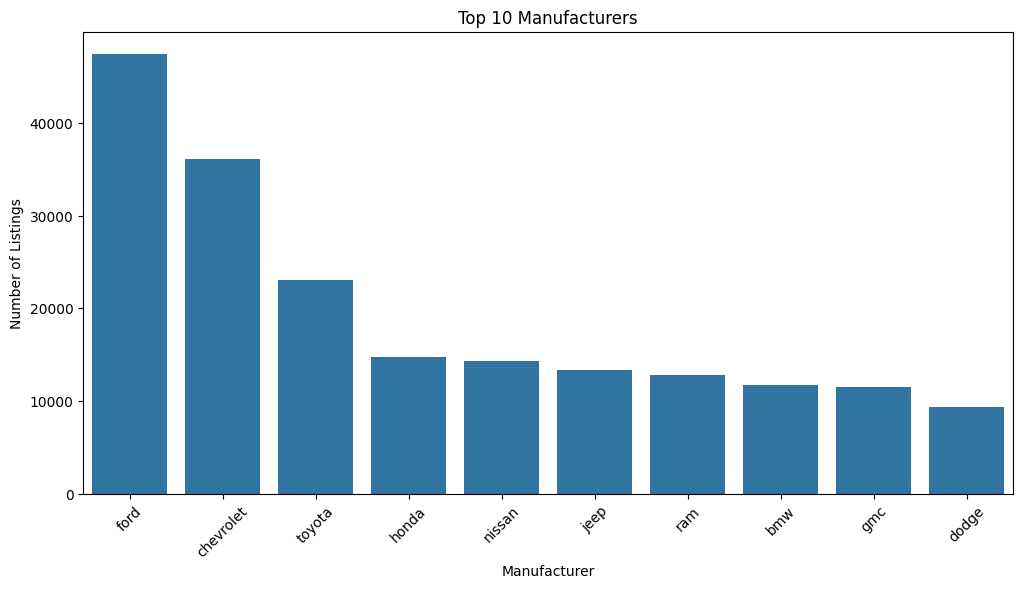

In [27]:
top_manufacturer=df['manufacturer'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_manufacturer.index,
    y=top_manufacturer.values
)
plt.title('Top 10 Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()

In [28]:
df.isnull().mean().mul(100)

Unnamed: 0       0.000000
price            0.000000
year             0.000000
manufacturer     0.000000
condition       38.385465
cylinders       42.726110
fuel             0.000000
odometer         0.000000
title_status     1.605501
transmission     0.000000
drive           30.137619
size            74.598539
type            18.413603
paint_color     27.374544
state            0.000000
dtype: float64

In [29]:
df=df.drop(columns=["size"])

In [30]:
df.isnull().mean().mul(100)

Unnamed: 0       0.000000
price            0.000000
year             0.000000
manufacturer     0.000000
condition       38.385465
cylinders       42.726110
fuel             0.000000
odometer         0.000000
title_status     1.605501
transmission     0.000000
drive           30.137619
type            18.413603
paint_color     27.374544
state            0.000000
dtype: float64

In [31]:
df=df.dropna(subset=[
    "condition",
    "cylinders",
    "title_status",
    "drive",
    "type",
    "paint_color"
])

In [32]:
df.isnull().mean().mul(100)

Unnamed: 0      0.0
price           0.0
year            0.0
manufacturer    0.0
condition       0.0
cylinders       0.0
fuel            0.0
odometer        0.0
title_status    0.0
transmission    0.0
drive           0.0
type            0.0
paint_color     0.0
state           0.0
dtype: float64

In [33]:
df.shape

(81543, 14)

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
encoder={}
cat_cols=[
    "manufacturer",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color",
    "state",
]
for col in cat_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col].astype(str))
    encoder[col]=le

In [36]:
X=df.drop(columns="price")
y=np.log1p(df['price'])

In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [38]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [39]:
from xgboost import XGBRegressor

In [40]:
xgb_default=XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)
xgb_default.fit(X_train_scaled,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [41]:
default_pred_log=xgb_default.predict(X_test_scaled)
y_test_exp=np.expm1(y_test)
default_pred_exp=np.expm1(default_pred_log)
default_mae=mean_absolute_error(y_test_exp,default_pred_exp)
default_mse=mean_absolute_error(y_test_exp,default_pred_exp)
default_r2=r2_score(y_test_exp,default_pred_exp)
print(f"MAE = {default_mae:.2f}")
print(f"MSE = {default_mse:.2f}")
print(f"R2 = {default_r2:.4f}")

MAE = 2482.29
MSE = 2482.29
R2 = 0.9023


In [42]:
print("\n=== HYPERPARAMETER OPTIMIZATION ===")

xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.03, 0.05],
    'max_depth': [6, 9],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


=== HYPERPARAMETER OPTIMIZATION ===


In [44]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)



In [45]:
grid_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05], 'max_depth': [6, 9], 'n_estimators': [200, 300], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_m

In [46]:
print(grid_search.best_params_)
print(f"\n Best Cross-Validation R2 Score: "f"{grid_search.best_score_:.4f}")
best_xgb=grid_search.best_estimator_

{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 300, 'subsample': 0.8}

 Best Cross-Validation R2 Score: 0.9045


In [47]:
models={
    "Linear Regression (Baseline)":LinearRegression(),
    "XGBoost Default":xgb_default,
    "XGBoost Optimized":best_xgb
}
result={}
pred_dict={}

In [48]:
for name,model in models.items():
    if name!="XGBoost Default":
        model.fit(X_train_scaled,y_train)
    log_pred=model.predict(X_test_scaled)
    y_pred_exp=np.expm1(log_pred)
    pred_dict[name]=y_pred_exp
    mae = mean_absolute_error(
        y_test_exp,
        y_pred_exp
    )

    mse = mean_squared_error(
        y_test_exp,
        y_pred_exp
    )

    r2 = r2_score(
        y_test_exp,
        y_pred_exp
    )
    result[name] = [mae, mse, r2]
    print(f"\n{name}")
    print(f"MAE = {mae:.2f}")
    print(f"MSE = {mse:.2f}")
    print(f"R2 = {r2:.4f}")



Linear Regression (Baseline)
MAE = 4753.84
MSE = 49885304.90
R2 = 0.6847

XGBoost Default
MAE = 2482.29
MSE = 15460935.06
R2 = 0.9023

XGBoost Optimized
MAE = 2176.99
MSE = 12834354.66
R2 = 0.9189


In [49]:
results_df=pd.DataFrame(
    result,
    index=["MAE","MSE","R2"]
).T
print("MODEL COMPARISON")
print(results_df)

MODEL COMPARISON
                                      MAE           MSE        R2
Linear Regression (Baseline)  4753.837190  4.988530e+07  0.684671
XGBoost Default               2482.286749  1.546094e+07  0.902270
XGBoost Optimized             2176.985646  1.283435e+07  0.918873


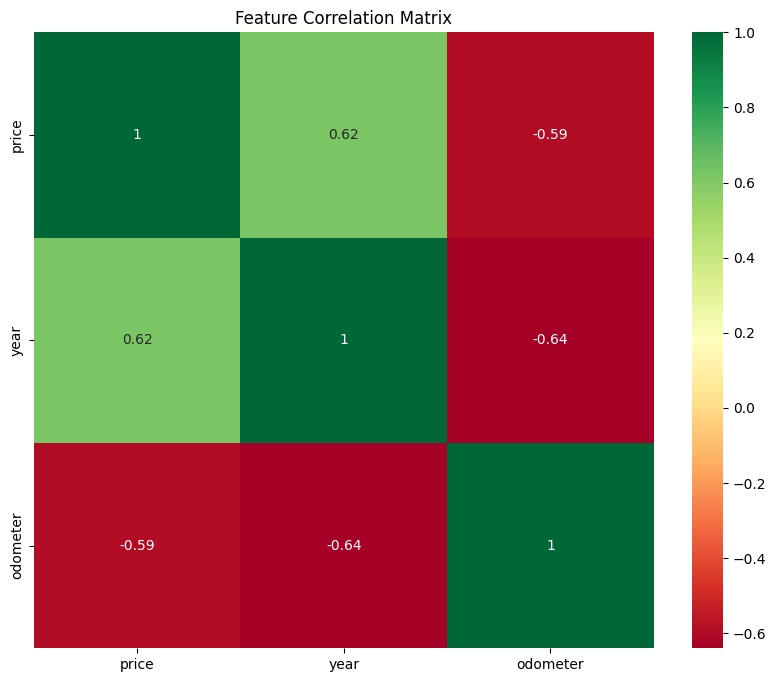

In [50]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df[["price","year","odometer"]].corr(),
    annot=True,
    cmap="RdYlGn"
    
)
plt.title("Feature Correlation Matrix")
plt.show()

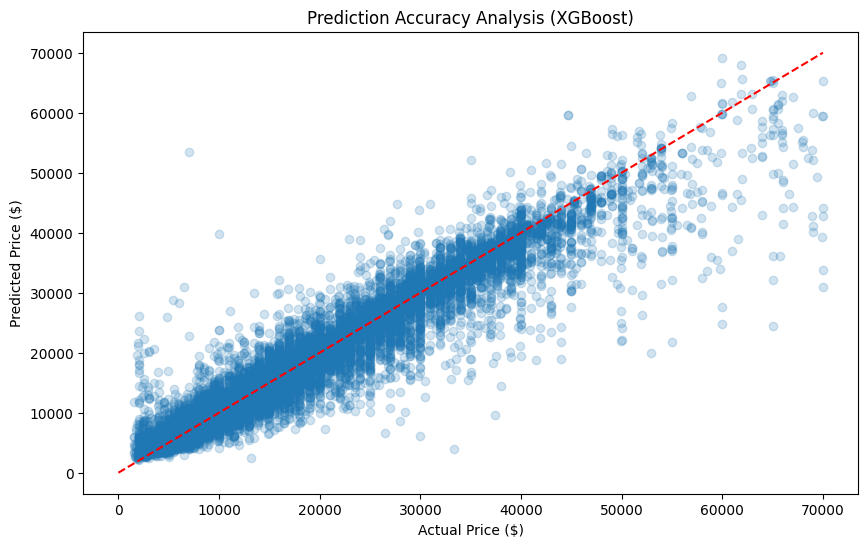

In [51]:
plt.figure(figsize=(10,6))
plt.scatter(y_test_exp,pred_dict["XGBoost Optimized"],alpha=0.2)
plt.plot([0,70000],[0,70000],'--r')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

plt.title('Prediction Accuracy Analysis (XGBoost)')
plt.show()

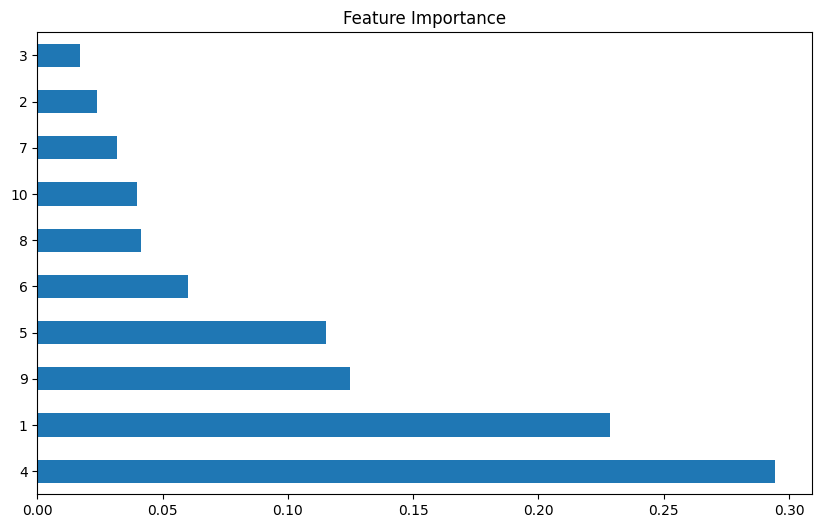

In [52]:
plt.figure(figsize=(10,6))
feat_importances=pd.Series(
    models["XGBoost Optimized"].feature_importances_
)
feat_importances.nlargest(10).plot(kind="barh")
plt.title('Feature Importance')
plt.show()

In [53]:
def predict_car(
    Unnamed: 0,
    year,
    odo,
    man,
    cond,
    cyl,
    fuel,
    trans,
    drv,
    body,
    st
):
    data = {
        "Unnamed: 0": 0,
        "year": year,
        "manufacturer": man,      # check column name
        "condition": cond,
        "cylinders": cyl,
        "fuel": fuel,
        "odometer": odo,
        "title_status": "clean",
        "transmission": trans,
        "drive": drv,
        "type": body,
        "paint_color": "custom",
        "state": st
    }
    cols = [c for c in X.columns if c != "Unnamed: 0"]

    input_df = pd.DataFrame([data])
    input_df = input_df.reindex(columns=cols)

    input_df = pd.DataFrame([data])

    input_df = input_df[X.columns]

    for col in cat_cols:
        input_df[col] = encoder[col].transform(
            input_df[col].astype(str)
        )

    scaled = scaler.transform(input_df)

    result = np.expm1(
        models["XGBoost Optimized"].predict(scaled)
    )

    return result[0]

In [54]:
test_res = predict_car(
    0,
    2019,
    45000,
    'ford',
    'excellent',
    '8 cylinders',
    'gas',
    'automatic',
    'rwd',
    'pickup',
    'tx'
)

print("\n--- TEST PREDICTION ---")

print("TEST PREDICTION")
print(
    f"Ford Pickup 2019: "
    f"Rs{test_res:.2f}"
)


--- TEST PREDICTION ---
TEST PREDICTION
Ford Pickup 2019: Rs35597.26
